# Step 1 — 1D Linear Convection

*13 Steps to Navier-Stokes with somax (inspired by Lorena Barba's CFD Python)*

The linear convection equation is the simplest PDE in computational fluid dynamics. It describes how a disturbance propagates through a medium at a constant speed without changing shape (in the continuous limit). Mastering this equation gives you the foundation for every subsequent step.

**What you'll learn:**

1. The physics of linear wave propagation and the CFL condition
2. How to set up a 1D PDE model in somax
3. How to compare numerical output against the analytical solution
4. How to differentiate through the simulation with `eqx.filter_grad`

## The PDE

$$
\frac{\partial u}{\partial t} + c \frac{\partial u}{\partial x} = 0
$$

where $c$ is the constant wave speed. The exact solution for an initial condition $u(x, 0) = u_0(x)$ is simply:

$$
u(x, t) = u_0(x - ct)
$$

The initial profile translates to the right at speed $c$ without distortion. This is pure **advection** — no diffusion, no steepening.

### The CFL condition

The Courant-Friedrichs-Lewy (CFL) number $\nu_{\mathrm{CFL}} = c \, \Delta t / \Delta x$ must satisfy $\nu_{\mathrm{CFL}} \le 1$ for explicit upwind schemes. If the numerical domain of dependence does not contain the physical domain of dependence, the scheme is unstable.

## Grid layout and boundary conditions

somax uses the **Arakawa C-grid** from finitevolX. In 1D, scalar fields (like $u$) live at **T-points** (cell centres) and fluxes are computed at **U-points** (cell edges):

```
 ghost                    interior                     ghost
 ┌─────┬──────┬──────┬──────┬──────┬──────┬──────┬─────┐
 │  G  │  T₁  │  T₂  │  T₃  │ ···  │ Tₙ₋₁│  Tₙ  │  G  │
 └──┬──┴──┬───┴──┬───┴──┬───┴──┬───┴──┬───┴──┬───┴──┬──┘
    U₀    U₁     U₂     U₃           Uₙ₋₁    Uₙ    Uₙ₊₁
         ←── dx ──→
```

- **T-points** (indices `1:-1`): where `u` is stored and updated
- **U-points**: where `Difference1D` computes derivatives
- **Ghost cells** (indices `0` and `-1`): filled by BCs before each RHS evaluation

**Periodic BCs** copy the last interior value into the opposite ghost cell:

```
 u[0] = u[-2]      (left ghost ← rightmost interior)
 u[-1] = u[1]      (right ghost ← leftmost interior)
```

This makes the domain wrap around so waves that exit one side re-enter from the other.

In [1]:
from __future__ import annotations

import diffrax as dfx
import equinox as eqx
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

from somax.models import LinearConvection1D, LinearConvection1DState

## 1. Create the model

`LinearConvection1D.create()` builds a model on a 1D Arakawa C-grid with `nx` interior cells spanning a domain of length `Lx`. The wave speed `c` is a differentiable parameter visible to `jax.grad`.

In [2]:
nx, Lx, c = 200, 4.0, 1.0
model = LinearConvection1D.create(nx=nx, Lx=Lx, c=c)

print(f"Grid: Nx={model.grid.Nx} (includes 2 ghost cells), dx={model.grid.dx:.4f}")
print(f"Wave speed c = {float(model.params.c):.1f}")

Grid: Nx=202 (includes 2 ghost cells), dx=0.0200
Wave speed c = 1.0


## 2. Initial condition

We use a Gaussian bump centered at $x = 1.0$ with standard deviation $\sigma = 0.2$. The state array has shape `(Nx,)` which includes the two ghost cells that enforce periodic boundary conditions.

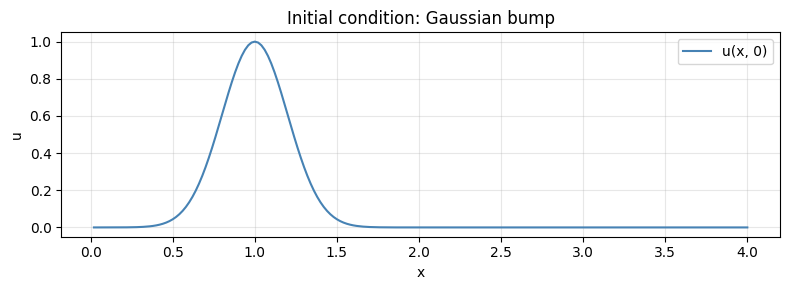

In [3]:
x = jnp.arange(model.grid.Nx) * model.grid.dx

mu0, sigma0 = 1.0, 0.2
u0 = jnp.exp(-0.5 * ((x - mu0) / sigma0) ** 2)

state0 = LinearConvection1DState(u=u0)

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(x[1:-1], u0[1:-1], color="steelblue", lw=1.5, label="u(x, 0)")
ax.set_xlabel("x")
ax.set_ylabel("u")
ax.set_title("Initial condition: Gaussian bump")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 3. Forward simulation

We integrate from $t = 0$ to $t = 0.5$ using `model.integrate()`. The method wraps `diffrax.diffeqsolve` and automatically applies periodic boundary conditions at every RHS evaluation.

In [4]:
t0, t1, dt = 0.0, 0.5, 0.002
ts = jnp.linspace(t0, t1, 6)  # save at 6 snapshots

sol = model.integrate(
    state0,
    t0=t0,
    t1=t1,
    dt=dt,
    saveat=dfx.SaveAt(ts=ts),
)

print(f"Trajectory shape: u={sol.ys.u.shape}")
print(f"CFL number: c * dt / dx = {c * dt / model.grid.dx:.3f}")

Trajectory shape: u=(6, 202)
CFL number: c * dt / dx = 0.100


## 4. Visualize the wave propagation

The Gaussian translates to the right at speed $c = 1$. After $t = 0.5$ it should have moved by $\Delta x = 0.5$.

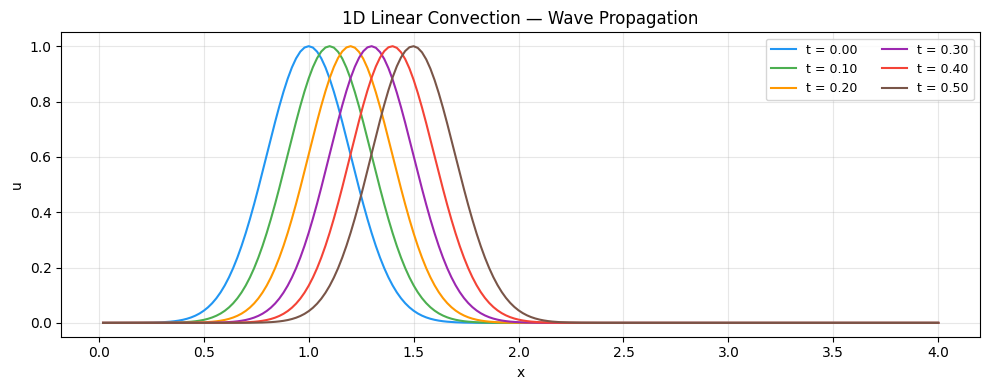

In [5]:
colors_snap = ["#2196F3", "#4CAF50", "#FF9800", "#9C27B0", "#F44336", "#795548"]

fig, ax = plt.subplots(figsize=(10, 4))
for i, t_snap in enumerate(ts):
    ax.plot(
        x[1:-1],
        sol.ys.u[i, 1:-1],
        color=colors_snap[i],
        lw=1.5,
        label=f"t = {float(t_snap):.2f}",
    )
ax.set_xlabel("x")
ax.set_ylabel("u")
ax.set_title("1D Linear Convection — Wave Propagation")
ax.legend(fontsize=9, ncol=2)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Comparison with the analytical solution

The exact solution is $u(x, t) = u_0(x - ct)$. With periodic BCs the shifted coordinate wraps around the domain.

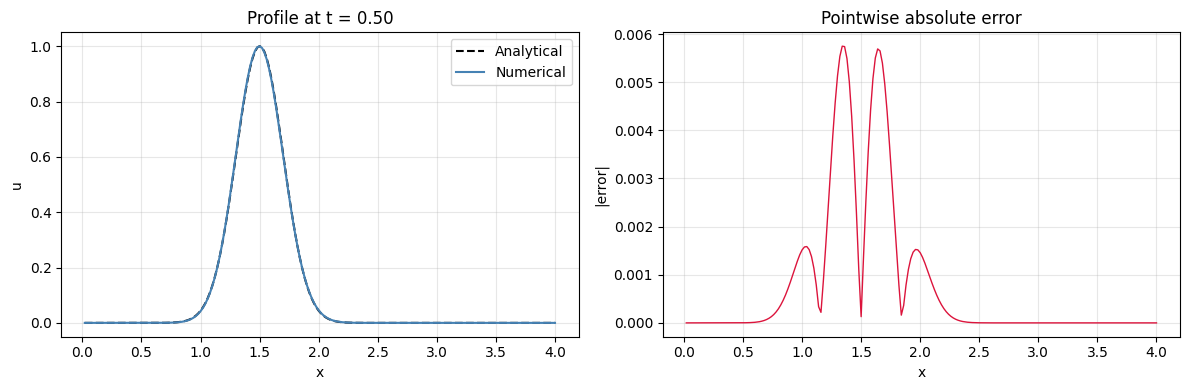

Max error: 0.005749
L2 error:  0.003391


In [6]:
u_final_numerical = sol.ys.u[-1]
x_shifted = (x - c * float(ts[-1])) % Lx
u_exact = jnp.exp(-0.5 * ((x_shifted - mu0) / sigma0) ** 2)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Overlay
ax = axes[0]
ax.plot(x[1:-1], u_exact[1:-1], "k--", lw=1.5, label="Analytical")
ax.plot(x[1:-1], u_final_numerical[1:-1], color="steelblue", lw=1.5, label="Numerical")
ax.set_xlabel("x")
ax.set_ylabel("u")
ax.set_title(f"Profile at t = {float(ts[-1]):.2f}")
ax.legend()
ax.grid(True, alpha=0.3)

# Error
ax = axes[1]
error = jnp.abs(u_final_numerical - u_exact)
ax.plot(x[1:-1], error[1:-1], color="crimson", lw=1.0)
ax.set_xlabel("x")
ax.set_ylabel("|error|")
ax.set_title("Pointwise absolute error")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Max error: {float(jnp.max(error[1:-1])):.6f}")
print(f"L2 error:  {float(jnp.sqrt(jnp.sum(error[1:-1] ** 2) * model.grid.dx)):.6f}")

## 6. Diagnostics — energy conservation

For the linear convection equation with periodic BCs, the total energy $E = \frac{1}{2} \int u^2 \, dx$ is conserved analytically. Numerical dissipation causes a slow decay.

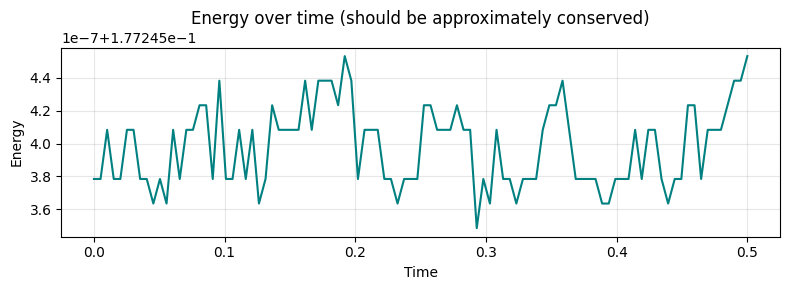

Energy: initial = 0.177245, final = 0.177245
Relative change: 0.0000%


In [7]:
ts_dense = jnp.linspace(t0, t1, 100)
sol_dense = model.integrate(
    state0,
    t0=t0,
    t1=t1,
    dt=dt,
    saveat=dfx.SaveAt(ts=ts_dense),
)

energy = jax.vmap(model.diagnose)(sol_dense.ys).energy

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(ts_dense, energy, color="teal", lw=1.5)
ax.set_xlabel("Time")
ax.set_ylabel("Energy")
ax.set_title("Energy over time (should be approximately conserved)")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Energy: initial = {float(energy[0]):.6f}, final = {float(energy[-1]):.6f}")
print(f"Relative change: {abs(float(energy[-1] - energy[0])) / float(energy[0]):.4%}")

## 7. Differentiability demo

One of the key advantages of somax is that every simulation is end-to-end differentiable. We define a loss function and compute $\partial \mathcal{L} / \partial c$ — the gradient of the loss with respect to the wave speed parameter.

In [8]:
# Target: we want the final profile to match a Gaussian at x=1.5
x_target = 1.5
u_target = jnp.exp(-0.5 * ((x - x_target) / sigma0) ** 2)


@eqx.filter_grad
def grad_wrt_model(m):
    """Gradient of MSE loss w.r.t. all differentiable model parameters."""
    sol = m.integrate(state0, t0=0.0, t1=0.5, dt=0.002)
    u_pred = sol.ys.u[-1]
    return jnp.mean((u_pred[1:-1] - u_target[1:-1]) ** 2)


grads = grad_wrt_model(model)

print("--- Gradient w.r.t. model parameters ---")
print(f"  dL/d(c) = {float(grads.params.c):.6f}")
print()
print("The gradient tells us how to adjust the wave speed to move")
print("the final profile closer to the target location x = 1.5.")

--- Gradient w.r.t. model parameters ---
  dL/d(c) = -0.001377

The gradient tells us how to adjust the wave speed to move
the final profile closer to the target location x = 1.5.


### Joint gradient -- parameters and initial state

We can simultaneously compute gradients with respect to both the wave speed $c$ and the initial condition $u_0$. This is the foundation for bi-level optimisation (e.g. weak-constraint 4D-Var).

In [9]:
def loss_joint(state0, model):
    sol = model.integrate(state0, t0=0.0, t1=0.2, dt=0.002)
    return jnp.sum(sol.ys.u**2)


grads_u0, grads_model = jax.grad(loss_joint, argnums=(0, 1))(state0, model)
print("--- Joint gradient ---")
print(f"  dL/d(u0) max = {float(jnp.max(jnp.abs(grads_u0.u))):.4f}")
print(f"  dL/d(c)      = {float(grads_model.params.c):.4f}")

--- Joint gradient ---
  dL/d(u0) max = 2.0000
  dL/d(c)      = -0.0000


### Comparing adjoint methods

diffrax provides several adjoint methods for differentiating through ODE solves. `RecursiveCheckpointAdjoint` (the default) gives exact gradients with $O(\sqrt{N})$ memory. `DirectAdjoint` stores the full trajectory ($O(N)$ memory) but can be faster for short integrations.

In [10]:
import time


def timed_grad(adjoint, label):
    @eqx.filter_grad
    def fn(m):
        sol = m.integrate(state0, t0=0.0, t1=0.2, dt=0.002, adjoint=adjoint)
        return jnp.sum(sol.ys.u**2)

    g = fn(model)
    jax.block_until_ready(g.params.c)
    t_start = time.perf_counter()
    g = fn(model)
    jax.block_until_ready(g.params.c)
    elapsed = time.perf_counter() - t_start
    print(f"  {label:35s}  dL/d(c)={float(g.params.c):.4f}  ({elapsed:.4f}s)")


print("--- Adjoint method comparison ---")
timed_grad(dfx.RecursiveCheckpointAdjoint(), "RecursiveCheckpoint")
timed_grad(dfx.DirectAdjoint(), "Direct")

--- Adjoint method comparison ---


  RecursiveCheckpoint                  dL/d(c)=-0.0000  (4.1335s)


  Direct                               dL/d(c)=-0.0000  (3.0787s)


### Ensemble simulation with `jax.vmap`

We can run an ensemble of simulations with different initial conditions to explore sensitivity efficiently.

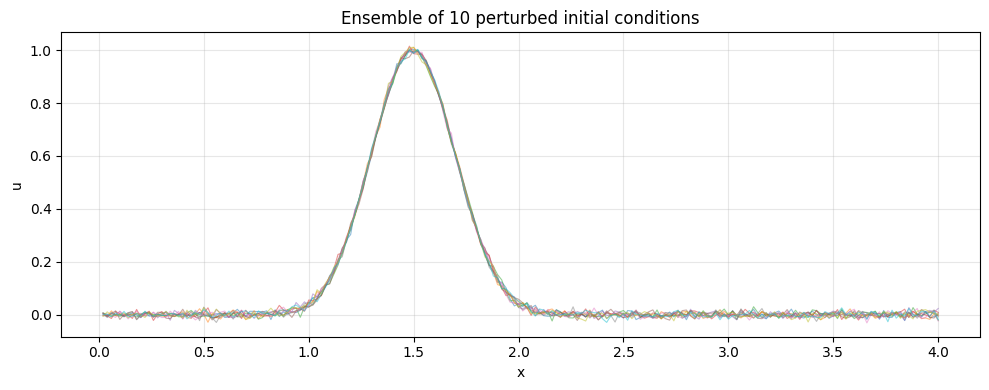

In [11]:
import jax.random as jrandom


n_ensemble = 10
key = jrandom.PRNGKey(42)
perturbations = 0.01 * jrandom.normal(key, shape=(n_ensemble, model.grid.Nx))
ensemble_u0 = state0.u[None, :] + perturbations


def integrate_one(u0_ens):
    s = LinearConvection1DState(u=u0_ens)
    return model.integrate(s, t0=0.0, t1=0.5, dt=0.002, saveat=dfx.SaveAt(t1=True))


ensemble_sol = eqx.filter_vmap(integrate_one)(ensemble_u0)

fig, ax = plt.subplots(figsize=(10, 4))
x_int = x[1:-1]
for j in range(n_ensemble):
    ax.plot(x_int, ensemble_sol.ys.u[j, -1, 1:-1], lw=0.8, alpha=0.5)
ax.set_xlabel("x")
ax.set_ylabel("u")
ax.set_title(f"Ensemble of {n_ensemble} perturbed initial conditions")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Summary

| Concept | somax API |
|---------|-----------|
| Create model | `LinearConvection1D.create(nx=200, Lx=4.0, c=1.0)` |
| Initial state | `LinearConvection1DState(u=...)` |
| Forward sim | `model.integrate(state0, t0, t1, dt, saveat=...)` |
| Diagnostics | `model.diagnose(state)` |
| Grad w.r.t. params | `eqx.filter_grad(loss)(model)` |

**Key takeaway:** Linear convection translates a signal without distortion. The CFL condition $c \Delta t / \Delta x \le 1$ governs stability.

**Next:** [Step 2 — Nonlinear Convection](step02_nonlinear_convection_1d) introduces amplitude-dependent wave speed and shock formation.